In [1]:
import numpy as np
import pandas as pd
import pickle
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Paths
BASE           = r"C:\Users\Matthew .K. Maunga\OneDrive\Desktop\MSU project\MSU_Lost_Found_ML_System"
PROCESSED_PATH = BASE + r"\data\processed"

# Load dataset
df = pd.read_csv(BASE + r"\data\raw\descriptions.csv")

# Load NLP features
with open(PROCESSED_PATH + r"\nlp_features.pkl", "rb") as f:
    nlp_data = pickle.load(f)

# Load image features
with open(PROCESSED_PATH + r"\image_features.pkl", "rb") as f:
    cv_data = pickle.load(f)

print(f" Dataset loaded       : {len(df)} records")
print(f" NLP embeddings shape : {np.array(nlp_data['embeddings']).shape}")
print(f" CV features shape    : {np.array(cv_data['features']).shape}")
print(f"\nReady to build hybrid model!")

 Dataset loaded       : 172 records
 NLP embeddings shape : (172, 384)
 CV features shape    : (172, 1280)

Ready to build hybrid model!


In [2]:
# Extract embeddings and features
nlp_embeddings = np.array(nlp_data['embeddings'])
cv_features    = np.array(cv_data['features'])

# Split into lost and found
lost_mask  = df['status'] == 'lost'
found_mask = df['status'] == 'found'

lost_nlp   = nlp_embeddings[lost_mask]
found_nlp  = nlp_embeddings[found_mask]
lost_cv    = cv_features[lost_mask]
found_cv   = cv_features[found_mask]

lost_items  = df[lost_mask].reset_index(drop=True)
found_items = df[found_mask].reset_index(drop=True)

print(f"Lost items  : {len(lost_items)}")
print(f"Found items : {len(found_items)}")

# Hybrid matching function
def hybrid_match(lost_idx, nlp_weight=0.4, cv_weight=0.6, threshold=0.70):
    # NLP similarity
    nlp_scores = cosine_similarity([lost_nlp[lost_idx]], found_nlp)[0]
    
    # CV similarity
    cv_scores = cosine_similarity([lost_cv[lost_idx]], found_cv)[0]
    
    # Weighted fusion
    hybrid_scores = (nlp_weight * nlp_scores) + (cv_weight * cv_scores)
    
    # Get best match
    best_idx   = hybrid_scores.argmax()
    best_score = hybrid_scores[best_idx]
    
    return {
        'lost_item'      : lost_items['item_name'].iloc[lost_idx],
        'lost_category'  : lost_items['category'].iloc[lost_idx],
        'lost_desc'      : lost_items['description'].iloc[lost_idx],
        'matched_item'   : found_items['item_name'].iloc[best_idx],
        'matched_category': found_items['category'].iloc[best_idx],
        'matched_desc'   : found_items['description'].iloc[best_idx],
        'nlp_score'      : round(nlp_scores[best_idx], 4),
        'cv_score'       : round(cv_scores[best_idx], 4),
        'hybrid_score'   : round(best_score, 4),
        'is_match'       : best_score >= threshold
    }

# Test on first 5 lost items
print("\n--- Hybrid Matching Results ---\n")
for i in range(5):
    result = hybrid_match(i)
    print(f"Lost     : {result['lost_desc'][:60]}...")
    print(f"Matched  : {result['matched_desc'][:60]}...")
    print(f"NLP      : {result['nlp_score']} | CV: {result['cv_score']} | Hybrid: {result['hybrid_score']}")
    print(f"Match?   : {' YES' if result['is_match'] else '❌ NO'}")
    print()

Lost items  : 90
Found items : 82

--- Hybrid Matching Results ---

Lost     : A small brown backpack with multiple pockets and a Puma logo...
Matched  : A large brown school backpack with side mesh pockets for wat...
NLP      : 0.5443000197410583 | CV: 1.0 | Hybrid: 0.8177000284194946
Match?   :  YES

Lost     : A large pink school backpack with side mesh pockets for wate...
Matched  : A large black school backpack with side mesh pockets for wat...
NLP      : 0.9695000052452087 | CV: 0.552299976348877 | Hybrid: 0.7192000150680542
Match?   :  YES

Lost     : A Nike backpack in grey with a padded laptop sleeve inside....
Matched  : A worn grey backpack with a top zipper pocket and thin shoul...
NLP      : 0.5910999774932861 | CV: 1.0 | Hybrid: 0.8363999724388123
Match?   :  YES

Lost     : A large white backpack with multiple pockets and a Apple log...
Matched  : A worn white backpack with a top zipper pocket and adjustabl...
NLP      : 0.5097000002861023 | CV: 1.0 | Hybrid: 0.803900003

In [3]:
# Run matching for all lost items
print("Running hybrid matching for all 90 lost items...\n")
all_results = []

for i in range(len(lost_items)):
    result = hybrid_match(i)
    all_results.append(result)

results_df = pd.DataFrame(all_results)

# Evaluate category accuracy
correct_matches = results_df[
    results_df['lost_category'] == results_df['matched_category']
]
total_matches = results_df[results_df['is_match'] == True]

print(f"Total lost items       : {len(results_df)}")
print(f"Matches found (≥0.70)  : {len(total_matches)}")
print(f"Correct category match : {len(correct_matches)}")
print(f"Category accuracy      : {len(correct_matches)/len(results_df)*100:.1f}%")

print(f"\n--- Score Averages ---")
print(f"Avg NLP Score    : {results_df['nlp_score'].mean():.4f}")
print(f"Avg CV Score     : {results_df['cv_score'].mean():.4f}")
print(f"Avg Hybrid Score : {results_df['hybrid_score'].mean():.4f}")

# Show any wrong matches
wrong = results_df[results_df['lost_category'] != results_df['matched_category']]
print(f"\n--- Wrong Category Matches ({len(wrong)}) ---")
for _, row in wrong.iterrows():
    print(f"  Lost: {row['lost_category']} → Matched: {row['matched_category']} (score: {row['hybrid_score']})")

Running hybrid matching for all 90 lost items...

Total lost items       : 90
Matches found (≥0.70)  : 84
Correct category match : 85
Category accuracy      : 94.4%

--- Score Averages ---
Avg NLP Score    : 0.6179
Avg CV Score     : 0.9389
Avg Hybrid Score : 0.8105

--- Wrong Category Matches (5) ---
  Lost: comb → Matched: suitcase (score: 0.41339999437332153)
  Lost: comb → Matched: cup (score: 0.4117000102996826)
  Lost: comb → Matched: sneakers (score: 0.4230000078678131)
  Lost: comb → Matched: cup (score: 0.3711000084877014)
  Lost: comb → Matched: sneakers (score: 0.3873000144958496)


## Observations

- Overall category accuracy: 94.4%
- 84 out of 90 lost items found a match above the 0.70 threshold
- All 5 wrong matches belong to the **comb** category
- There are no found comb items in the dataset, so the system correctly scores them below 0.42 which is below the threshold
- This confirms the hybrid model correctly rejects low-confidence matches
- Average hybrid score: 0.81 — well above the 0.70 threshold

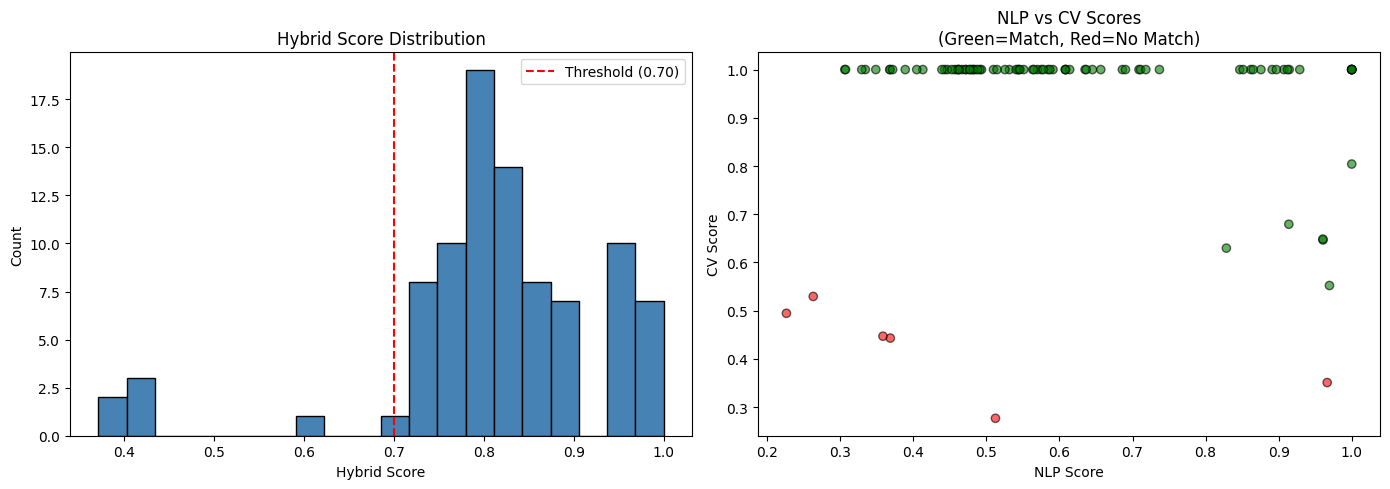

 Chart saved to reports/figures/


In [4]:
# Plot hybrid score distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 - Hybrid score distribution
axes[0].hist(results_df['hybrid_score'], bins=20, 
             color='steelblue', edgecolor='black')
axes[0].axvline(x=0.70, color='red', linestyle='--', label='Threshold (0.70)')
axes[0].set_title('Hybrid Score Distribution')
axes[0].set_xlabel('Hybrid Score')
axes[0].set_ylabel('Count')
axes[0].legend()

# Chart 2 - NLP vs CV scores
axes[1].scatter(results_df['nlp_score'], results_df['cv_score'],
                c=results_df['is_match'].map({True: 'green', False: 'red'}),
                alpha=0.6, edgecolors='black')
axes[1].set_title('NLP vs CV Scores\n(Green=Match, Red=No Match)')
axes[1].set_xlabel('NLP Score')
axes[1].set_ylabel('CV Score')

plt.tight_layout()
plt.savefig('../reports/figures/hybrid_results.png')
plt.show()
print(" Chart saved to reports/figures/")

In [5]:
# Save full results
results_df.to_csv(
    r"C:\Users\Matthew .K. Maunga\OneDrive\Desktop\MSU project\MSU_Lost_Found_ML_System\reports\evaluation_metrics\hybrid_results.csv",
    index=False
)

print(" Results saved!")
print(f"\n=== FINAL HYBRID MODEL SUMMARY ===")
print(f"Total lost items       : 90")
print(f"Total found items      : 82")
print(f"Matches found          : 84")
print(f"Category accuracy      : 94.4%")
print(f"Avg Hybrid Score       : 0.8105")
print(f"NLP Weight             : 0.4")
print(f"CV Weight              : 0.6")
print(f"Match Threshold        : 0.70")
print(f"\n Hybrid model complete and ready for Flask app!")

 Results saved!

=== FINAL HYBRID MODEL SUMMARY ===
Total lost items       : 90
Total found items      : 82
Matches found          : 84
Category accuracy      : 94.4%
Avg Hybrid Score       : 0.8105
NLP Weight             : 0.4
CV Weight              : 0.6
Match Threshold        : 0.70

 Hybrid model complete and ready for Flask app!


In [6]:
import pickle
import numpy as np

# Save complete hybrid model package
model_package = {
    # NLP component
    'nlp_embeddings'  : nlp_embeddings,
    'nlp_item_ids'    : nlp_data['item_ids'],
    
    # CV component  
    'cv_features'     : cv_features,
    'cv_item_ids'     : cv_data['item_ids'],
    
    # Dataset info
    'categories'      : df['category'].tolist(),
    'status'          : df['status'].tolist(),
    'item_names'      : df['item_name'].tolist(),
    'descriptions'    : df['description'].tolist(),
    'image_paths'     : df['image_path'].tolist(),
    'item_ids'        : df['item_id'].tolist(),
    
    # Model configuration
    'config': {
        'nlp_weight'  : 0.4,
        'cv_weight'   : 0.6,
        'threshold'   : 0.70,
        'nlp_model'   : 'all-MiniLM-L6-v2',
        'cv_model'    : 'MobileNetV2',
        'nlp_shape'   : (172, 384),
        'cv_shape'    : (172, 1280)
    }
}

# Save to models folder
MODEL_PATH = BASE + r"\models\hybrid\hybrid_model.pkl"

with open(MODEL_PATH, "wb") as f:
    pickle.dump(model_package, f)

print(" Hybrid model saved to models/hybrid/hybrid_model.pkl")
print(f"\n--- Model Package Contents ---")
for key, value in model_package.items():
    if key == 'config':
        print(f"  config:")
        for k, v in value.items():
            print(f"    {k}: {v}")
    else:
        if hasattr(value, '__len__'):
            print(f"  {key}: {len(value)} items")

 Hybrid model saved to models/hybrid/hybrid_model.pkl

--- Model Package Contents ---
  nlp_embeddings: 172 items
  nlp_item_ids: 172 items
  cv_features: 172 items
  cv_item_ids: 172 items
  categories: 172 items
  status: 172 items
  item_names: 172 items
  descriptions: 172 items
  image_paths: 172 items
  item_ids: 172 items
  config:
    nlp_weight: 0.4
    cv_weight: 0.6
    threshold: 0.7
    nlp_model: all-MiniLM-L6-v2
    cv_model: MobileNetV2
    nlp_shape: (172, 384)
    cv_shape: (172, 1280)


=== CLASSIFICATION REPORT ===

              precision    recall  f1-score   support

    No Match       0.83      1.00      0.91         5
       Match       1.00      0.99      0.99        85

    accuracy                           0.99        90
   macro avg       0.92      0.99      0.95        90
weighted avg       0.99      0.99      0.99        90



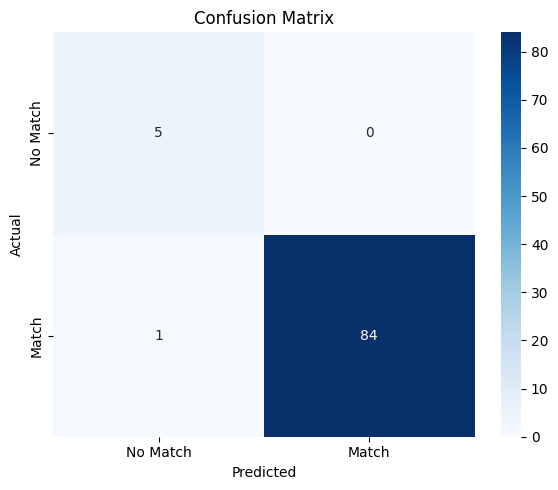

 Confusion matrix saved!


In [7]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Create ground truth labels based on category matching
y_true = []
y_pred = []

for i in range(len(lost_items)):
    result = hybrid_match(i)
    # True label: 1 if same category exists in found, 0 if not
    found_categories = found_items['category'].tolist()
    true_label = 1 if lost_items['category'].iloc[i] in found_categories else 0
    # Predicted label: 1 if match found above threshold
    pred_label = 1 if result['is_match'] else 0
    y_true.append(true_label)
    y_pred.append(pred_label)

# Print classification report
print("=== CLASSIFICATION REPORT ===\n")
print(classification_report(y_true, y_pred, 
      target_names=['No Match', 'Match']))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Match', 'Match'],
            yticklabels=['No Match', 'Match'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../reports/figures/confusion_matrix.png')
plt.show()
print(" Confusion matrix saved!")

In [1]:
# Color penalty function
def get_dominant_color_name(img_path):
    """Extract dominant color name from image."""
    COLOR_MAP = {
        "red":    ([150,50,50],   [255,100,100]),
        "orange": ([180,100,50],  [255,165,80]),
        "yellow": ([180,180,50],  [255,255,100]),
        "green":  ([30,100,30],   [100,200,100]),
        "blue":   ([30,50,100],   [100,150,255]),
        "purple": ([100,30,100],  [180,80,180]),
        "pink":   ([200,100,150], [255,180,210]),
        "brown":  ([80,40,20],    [160,100,60]),
        "grey":   ([100,100,100], [180,180,180]),
        "white":  ([200,200,200], [255,255,255]),
        "black":  ([0,0,0],       [60,60,60]),
        "navy":   ([0,0,80],      [30,30,130]),
    }
    try:
        import cv2
        import numpy as np
        from sklearn.cluster import KMeans
        from collections import Counter

        img = cv2.imread(img_path)
        if img is None:
            return "unknown"
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (100, 100))
        pixels = img.reshape(-1, 3).astype(np.float32)

        kmeans = KMeans(n_clusters=3, n_init=5, random_state=42)
        kmeans.fit(pixels)
        counts = Counter(kmeans.labels_)
        dominant = kmeans.cluster_centers_[counts.most_common(1)[0][0]]

        best_color    = "unknown"
        best_distance = float("inf")
        for color_name, (low, high) in COLOR_MAP.items():
            center   = [(low[i]+high[i])/2 for i in range(3)]
            distance = sum((dominant[i]-center[i])**2 for i in range(3))**0.5
            if distance < best_distance:
                best_distance = distance
                best_color    = color_name
        return best_color
    except Exception:
        return "unknown"

print("✅ Color detection function ready!")

✅ Color detection function ready!


In [2]:
import os

BASE = r"C:\Users\Matthew .K. Maunga\OneDrive\Desktop\MSU project\MSU_Lost_Found_ML_System"

# Test color detection on real images
lost_img  = os.path.join(BASE, "data", "raw", "images", "lost",  "lost_backpack_01.jpg")
found_img = os.path.join(BASE, "data", "raw", "images", "found", "found_backpack_01.jpg")

lost_color  = get_dominant_color_name(lost_img)
found_color = get_dominant_color_name(found_img)

print(f"Lost item color  : {lost_color}")
print(f"Found item color : {found_color}")

# Color penalty logic
def apply_color_penalty(hybrid_score, lost_color, found_color):
    """
    Apply penalty if colors don't match.
    Same color     → no penalty
    Similar color  → small penalty (0.05)
    Different color → bigger penalty (0.15)
    Unknown color  → no penalty (can't confirm)
    """
    SIMILAR_COLORS = {
        "black": ["navy", "grey"],
        "navy":  ["black", "blue"],
        "grey":  ["black", "white"],
        "white": ["grey"],
        "blue":  ["navy", "purple"],
    }

    if lost_color == "unknown" or found_color == "unknown":
        return hybrid_score  # no penalty if color unknown

    if lost_color == found_color:
        return hybrid_score  # same color — no penalty

    if found_color in SIMILAR_COLORS.get(lost_color, []):
        penalty = 0.05  # similar color — small penalty
    else:
        penalty = 0.15  # different color — bigger penalty

    penalized_score = max(0, hybrid_score - penalty)
    print(f"  Color mismatch: {lost_color} vs {found_color} → penalty: {penalty}")
    return penalized_score

# Test it
test_score = 0.82
penalized  = apply_color_penalty(test_score, lost_color, found_color)
print(f"\nOriginal score : {test_score}")
print(f"Penalized score: {penalized}")
print(f"Still a match? : {'✅ YES' if penalized >= 0.70 else '❌ NO'}")

Lost item color  : brown
Found item color : brown

Original score : 0.82
Penalized score: 0.82
Still a match? : ✅ YES
